<font size=6><b>Lec.09 판매량 예측 (공모전_시계열)

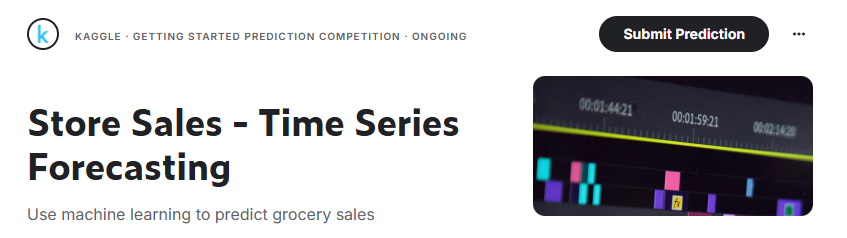
>https://www.kaggle.com/competitions/store-sales-time-series-forecasting

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split                     

#----------------------------------------------------------------------------------  DL모델 
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D
from keras.layers import Dense, LSTM, Dropout, GRU, Bidirectional
from tensorflow.keras.layers import Flatten, Dense, Rescaling
from tensorflow.keras.initializers import GlorotNormal    #Xavier

from tensorflow.keras.applications import MobileNetV2     #최소 이미지 크기 (32*32)

import math
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler

#----------------------------------------------------------------------------------  랜덤시드 고정 
import tensorflow as tf
tf.random.set_seed(54546)
np.random.seed(54546)

#----------------------------------------------------------------------------------  EDA : 이미지로드
import os
from tensorflow.keras.utils import load_img, img_to_array
from PIL import Image
from tensorflow.keras.utils import image_dataset_from_directory

#----------------------------------------------------------------------------------  조기종료
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
    


from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

sns.set()

#-------------------- 차트 관련 속성 (한글처리, 그리드) -----------
plt.rcParams['font.family']= 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# <b> Data Load

In [2]:
stores  = pd.read_csv("./dataset/store-sales/stores.csv")
oil     = pd.read_csv("./dataset/store-sales/oil.csv")
holiday = pd.read_csv("./dataset/store-sales/holidays_events.csv")

trans   = pd.read_csv("./dataset/store-sales/transactions.csv")

train   = pd.read_csv("./dataset/store-sales/train.csv")
test    = pd.read_csv("./dataset/store-sales/test.csv")
submit  = pd.read_csv("./dataset/store-sales/sample_submission.csv")

In [3]:
train.head(2)
train.info()
test.head(2)
test.info()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           int64  
 1   date         object 
 2   store_nbr    int64  
 3   family       object 
 4   sales        float64
 5   onpromotion  int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 137.4+ MB


,id,date,store_nbr,family,onpromotion
0,3000888,2017-08-16,1,AUTOMOTIVE,0
1,3000889,2017-08-16,1,BABY CARE,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28512 entries, 0 to 28511
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           28512 non-null  int64 
 1   date         28512 non-null  object
 2   store_nbr    28512 non-null  int64 
 3   family       28512 non-null  object
 4   onpromotion  28512 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 1.1+ MB


In [4]:
import pandas as pd

# 로드한 데이터프레임들을 딕셔너리로 묶기
dfs = {
            'stores': stores, 'oil': oil, 'holiday': holiday, 
            'trans': trans, 'train': train, 'test': test
        }

print(f"{'Table':<12} | {'Rows':<10} | {'Cols':<5} | {'Nulls':<7} | {'Duplicates'}")
print("-" * 60)

for name, df in dfs.items():
    rows, cols = df.shape
    nulls = df.isnull().sum().sum()  # 전체 결측치 합계
    dups = df.duplicated().sum()     # 중복 행 수
    print(f"{name:<12} | {rows:<10,} | {cols:<5} | {nulls:<7} | {dups}")

Table        | Rows       | Cols  | Nulls   | Duplicates
------------------------------------------------------------
stores       | 54         | 5     | 0       | 0
oil          | 1,218      | 2     | 43      | 0
holiday      | 350        | 6     | 0       | 0
trans        | 83,488     | 3     | 0       | 0
train        | 3,000,888  | 6     | 0       | 0
test         | 28,512     | 5     | 0       | 0


In [5]:
print(" ============== < stores > ============== ")
stores.head(2)
print()
print(" ============== < oil > ============== ")
oil.head(2)
print()
print(" ============== < holiday > ============== ")
holiday.head(2)
print()
print(" ============== < trans > ============== ")
trans.head(2)

 ============== < stores > ============== 


,store_nbr,city,state,type,cluster
0,1,Quito,Pichincha,D,13
1,2,Quito,Pichincha,D,13



 ============== < oil > ============== 


,date,dcoilwtico
0,2013-01-01,NaN
1,2013-01-02,93.14



 ============== < holiday > ============== 


,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False



 ============== < trans > ============== 


,date,store_nbr,transactions
0,2013-01-01,25,770
1,2013-01-02,1,2111


## <b> table간 관계 확인

In [6]:
# !pip install skimpy

In [7]:
from skimpy import skim

# 요약 통계와 히스토그램까지 한 번에 보여줌
skim(train)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                 Data Types                                                                │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                         │
│ ┃ Dataframe         ┃ Values  ┃ ┃ Column Type ┃ Count ┃                                                         │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                         │
│ │ Number of rows    │ 3000888 │ │ int64       │ 3     │                                                         │
│ │ Number of columns │ 6       │ │ string      │ 2     │                                                         │
│ └───────────────────┴─────────┘ │ float64     │ 1     │                                                         │
│                                 └─────────────┴───────┘                                                         │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━┳━━━━━┳━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━┳━━━━━┳━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━┓  │
│ ┃ column        ┃ NA  ┃ NA %  ┃ mean     ┃ sd      ┃ p0  ┃ p25     ┃ p50      ┃ p75      ┃ p100     ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━╇━━━━━╇━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━╇━━━━━╇━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━┩  │
│ │ id            │   0 │     0 │  1500000 │  866300 │   0 │  750200 │  1500000 │  2251000 │  3001000 │ ▇▇▇▇▇▇ │  │
│ │ store_nbr     │   0 │     0 │     27.5 │   15.59 │   1 │      14 │     27.5 │       41 │       54 │ ▇▇▇▇▇▇ │  │
│ │ sales         │   0 │     0 │    357.8 │    1102 │   0 │       0 │       11 │    195.8 │   124700 │   ▇    │  │
│ │ onpromotion   │   0 │     0 │    2.603 │   12.22 │   0 │       0 │        0 │        0 │      741 │   ▇    │  │
│ └───────────────┴─────┴───────┴──────────┴─────────┴─────┴─────────┴──────────┴──────────┴──────────┴────────┘  │
│                                                     string                                                      │
│ ┏━━━━━━━━┳━━━━┳━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━┓  │
│ ┃        ┃    ┃      ┃            ┃            ┃           ┃            ┃ chars per ┃ words per  ┃ total     ┃  │
│ ┃ column ┃ NA ┃ NA % ┃ shortest   ┃ longest    ┃ min       ┃ max        ┃ row       ┃ row        ┃ words     ┃  │
│ ┡━━━━━━━━╇━━━━╇━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━┩  │
│ │ date   │  0 │    0 │ 2013-01-01 │ 2013-01-01 │ 2013-01-0 │ 2017-08-15 │        10 │          1 │   3000888 │  │
│ │        │    │      │            │            │ 1         │            │           │            │           │  │
│ │ family │  0 │    0 │ DELI       │ SCHOOL AND │ AUTOMOTIV │ SEAFOOD    │      10.8 │        1.7 │   5001480 │  │
│ │        │    │      │            │ OFFICE     │ E         │            │           │            │           │  │
│ │        │    │      │            │ SUPPLIES   │           │            │           │            │           │  │
│ └────────┴────┴──────┴────────────┴────────────┴───────────┴────────────┴───────────┴────────────┴───────────┘  │
╰────────────────────────────────────────────────────── End ──────────────────────────────────────────────────────╯

In [8]:
# 각 테이블의 컬럼들을 비교해서 공통 컬럼(Join Key) 찾기
import pandas as pd

dfs = {'stores': stores, 'oil': oil, 'holiday': holiday, 'trans': trans, 'train': train}

print("### 데이터프레임 간 공통 컬럼 (ERD 관계 후보) ###")
for name1, df1 in dfs.items():
    for name2, df2 in dfs.items():
        if name1 < name2:
            common = set(df1.columns) & set(df2.columns)
            if common:
                print(f"[{name1}] <---> [{name2}] : {common}")

### 데이터프레임 간 공통 컬럼 (ERD 관계 후보) ###
[stores] <---> [trans] : {'store_nbr'}
[stores] <---> [train] : {'store_nbr'}
[oil] <---> [trans] : {'date'}
[oil] <---> [train] : {'date'}
[holiday] <---> [stores] : {'type'}
[holiday] <---> [oil] : {'date'}
[holiday] <---> [trans] : {'date'}
[holiday] <---> [train] : {'date'}
[train] <---> [trans] : {'store_nbr', 'date'}


In [9]:
# train을 기준으로 잡고 다른 테이블과의 접점 찾기
target = 'train'
other_dfs = {k: v for k, v in dfs.items() if k != target}

print(f"🎯 중심 테이블: [{target}]")
print("-" * 40)

for name, df in other_dfs.items():
    common = set(dfs[target].columns) & set(df.columns)
    if common:
        print(f"[{target}] <--- 연결 ---> [{name:<7}] | Key: {common}")
    else:
        print(f"[{target}]      (연결 안됨)      [{name:<7}]")

🎯 중심 테이블: [train]
----------------------------------------
[train] <--- 연결 ---> [stores ] | Key: {'store_nbr'}
[train] <--- 연결 ---> [oil    ] | Key: {'date'}
[train] <--- 연결 ---> [holiday] | Key: {'date'}
[train] <--- 연결 ---> [trans  ] | Key: {'store_nbr', 'date'}


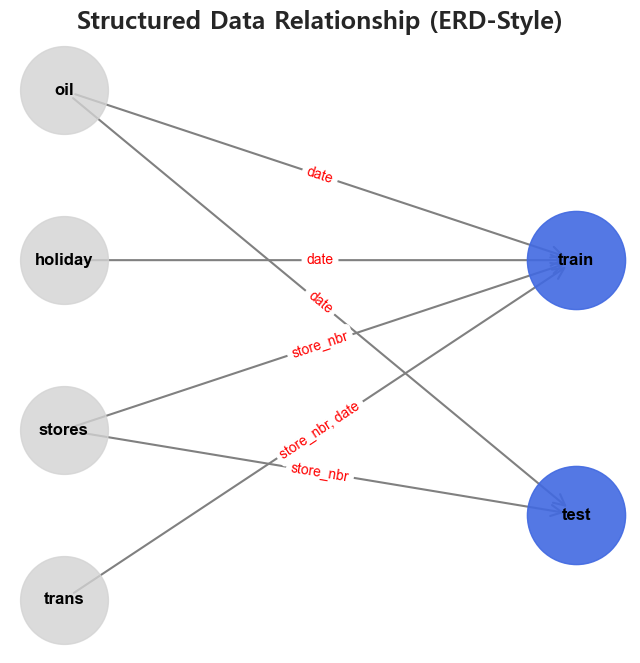

In [10]:
import networkx as nx
import matplotlib.pyplot as plt

# 1. 그래프 및 레이아웃 설정
G = nx.DiGraph() # 방향성이 있는 그래프

# 테이블 정의
main_tables = ['train', 'test']
ref_tables = ['stores', 'oil', 'holiday', 'trans']

# 2. 관계 정의 (정보의 흐름: 참조 -> 메인)
edges = [
    ('stores', 'train', 'store_nbr'),
    ('oil', 'train', 'date'),
    ('holiday', 'train', 'date'),
    ('trans', 'train', 'store_nbr, date'),
    ('stores', 'test', 'store_nbr'),
    ('oil', 'test', 'date')
]

for u, v, label in edges:
    G.add_edge(u, v, label=label)

# 3. 직관적인 좌표(pos) 직접 지정 (좌측: 참조, 우측: 메인)
pos = {
    'oil': [-1, 2],
    'holiday': [-1, 1],
    'stores': [-1, 0],
    'trans': [-1, -1],
    'train': [1, 1],
    'test': [1, -0.5]
}

# 4. 시각화 커스텀
plt.figure(figsize=(8,8))

# 노드 그리기 (메인과 참조 분리)
nx.draw_networkx_nodes(G, pos, nodelist=main_tables, node_color='royalblue', node_size=5000, alpha=0.9)
nx.draw_networkx_nodes(G, pos, nodelist=ref_tables, node_color='lightgray', node_size=4000, alpha=0.8)

# 엣지 및 라벨 그리기
nx.draw_networkx_edges(G, pos, edge_color='gray', arrowstyle='->', arrowsize=20, width=1.5)
nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold', font_color='black')

# 관계 키(Key) 표시
edge_labels = nx.get_edge_attributes(G, 'label')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red', font_size=10)

plt.title("Structured Data Relationship (ERD-Style)", fontsize=18, fontweight='bold')
plt.axis('off') # 축 숨기기
plt.show();

## <b> Table Merge

### <b> Merge Function

In [11]:
import pandas as pd

# 1. 전처리: 날짜 데이터 타입을 datetime으로 통일 (매우 중요!)
# 모든 테이블의 date 컬럼을 날짜형으로 변환해줍니다.
for df in [train, test, oil, holiday, trans]:
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'])

# 2. 메인 병합 함수 정의 (반복 작업을 줄이기 위함)
def merge_all_data(main_df):
    # (1) 매장 정보 합치기 (Join Key: store_nbr)
    res = main_df.merge(stores, on='store_nbr', how='left')
    
    # (2) 유가 정보 합치기 (Join Key: date)
    res = res.merge(oil, on='date', how='left')
    
    # (3) 공휴일 정보 합치기 (Join Key: date)
    # 중복 날짜 주의: holiday 테이블에 중복이 있을 수 있으므로 첫 번째 값 위주로 합칩니다.
    holiday_fixed = holiday.drop_duplicates(subset=['date'])
    res = res.merge(holiday_fixed, on='date', how='left')
    
    # (4) 거래량 정보 합치기 (Join Key: date, store_nbr)
    # 주의: trans는 train에만 있고 test에는 없을 수 있습니다.
    res = res.merge(trans, on=['date', 'store_nbr'], how='left')
    
    return res

### <b> Merge Result

In [12]:
# 3. 최종 병합 실행
df_train = merge_all_data(train)
df_test = merge_all_data(test)

# 4. 결과 확인
print("병합 후 Train 크기:", df_train.shape)
print("==========================================")
display(df_train.head(3))
df_train.info()

병합 후 Train 크기: (3000888, 17)


,id,date,store_nbr,family,sales,onpromotion,city,state,type_x,cluster,dcoilwtico,type_y,locale,locale_name,description,transferred,transactions
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13,NaN,Holiday,National,Ecuador,Primer dia del ano,False,NaN
1,1,2013-01-01,1,BABY CARE,0.0,0,Quito,Pichincha,D,13,NaN,Holiday,National,Ecuador,Primer dia del ano,False,NaN
2,2,2013-01-01,1,BEAUTY,0.0,0,Quito,Pichincha,D,13,NaN,Holiday,National,Ecuador,Primer dia del ano,False,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 17 columns):
 #   Column        Dtype         
---  ------        -----         
 0   id            int64         
 1   date          datetime64[ns]
 2   store_nbr     int64         
 3   family        object        
 4   sales         float64       
 5   onpromotion   int64         
 6   city          object        
 7   state         object        
 8   type_x        object        
 9   cluster       int64         
 10  dcoilwtico    float64       
 11  type_y        object        
 12  locale        object        
 13  locale_name   object        
 14  description   object        
 15  transferred   object        
 16  transactions  float64       
dtypes: datetime64[ns](1), float64(3), int64(4), object(9)
memory usage: 389.2+ MB


### <b> check_columns (상태 확인용)
> 데이터에 빈칸은 얼마나 있는지, 데이터 타입은 맞는지, 고유값은 몇 개나 되는지 등 테이블의 완성도를 확인
> 머지(Merge)가 끝난 후, 최종 결과물(df_train)이 분석하기에 깨끗한 상태인지 확인할 때 가장 유용

In [13]:
def check_columns(df):
    summary = pd.DataFrame({
        'Dtype': df.dtypes,
        'Nulls': df.isnull().sum(),
        'Null%': (df.isnull().sum() / len(df) * 100).round(2),
        'Nunique': df.nunique(),
        'Sample': [df[col].dropna().iloc[0] if not df[col].dropna().empty else "All NaN" for col in df.columns]
    })
    return summary

df_train.shape
display(check_columns(df_train))

(3000888, 17)

,Dtype,Nulls,Null%,Nunique,Sample
id,int64,0,0.00,3000888,0
date,datetime64[ns],0,0.00,1684,2013-01-01 00:00:00
store_nbr,int64,0,0.00,54,1
family,object,0,0.00,33,AUTOMOTIVE
sales,float64,0,0.00,379610,0.0
onpromotion,int64,0,0.00,362,0
city,object,0,0.00,22,Quito
state,object,0,0.00,16,Pichincha
type_x,object,0,0.00,5,D
cluster,int64,0,0.00,17,13


### <b> check_keys & null_summary (연결/누락 확인용)
> 데이터 통합 과정에서 발생하는 데이터 유실을 막는 가이드라인 역할

> check_keys: "이 테이블이랑 저 테이블을 합쳐도 될까? 없는 데이터가 있나?"를 조인 전에 미리 파악
> null_summary: 머지 후에 값이 왜 비었는지를 추적합니다. (예: "아, 기름값 데이터가 없는 날짜가 481일이나 되는구나")


In [14]:
# 1. 머지 전: 키(Key) 존재 여부 체크 함수
def check_keys(main, ref, key, name):
    main_keys = set(main[key].unique())
    ref_keys = set(ref[key].unique())
    
    missing = main_keys - ref_keys
    if missing:
        print(f"⚠️ [{name}] 테이블에 없는 {key}가 메인에 {len(missing)}개 존재합니다.")
        print(f"예시: {list(missing)[:5]}")
    else:
        print(f"✅ [{name}] 모든 {key}가 참조 테이블에 존재합니다.")

# 실행 예시
check_keys(train, stores, 'store_nbr', 'stores')
check_keys(train, oil, 'date', 'oil')

print("-" * 30)

# 2. 머지 후: 결측치 비율 확인 (얼마나 비어있나?)
# df_train.info() 이후에 이걸 돌려보세요.
null_counts = df_train.isnull().sum()
null_pct = (null_counts / len(df_train)) * 100
null_summary = pd.concat([null_counts, null_pct], axis=1, keys=['Counts', 'Percent (%)'])
display(null_summary[null_summary['Counts'] > 0])

✅ [stores] 모든 store_nbr가 참조 테이블에 존재합니다.
⚠️ [oil] 테이블에 없는 date가 메인에 481개 존재합니다.
예시: [Timestamp('2016-03-05 00:00:00'), Timestamp('2014-07-19 00:00:00'), Timestamp('2014-07-26 00:00:00'), Timestamp('2015-08-02 00:00:00'), Timestamp('2016-05-21 00:00:00')]
------------------------------


,Counts,Percent (%)
dcoilwtico,928422,30.938242
type_y,2551824,85.035629
locale,2551824,85.035629
locale_name,2551824,85.035629
description,2551824,85.035629
transferred,2551824,85.035629
transactions,245784,8.190376


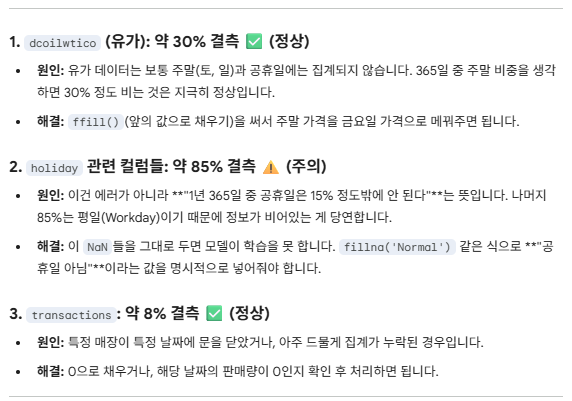

> <b><big>만약 돌리는거 너무 오래 돌리면 코랩 써서 TPU 등 활용하는게 속도가 빠름  </b></big><br>

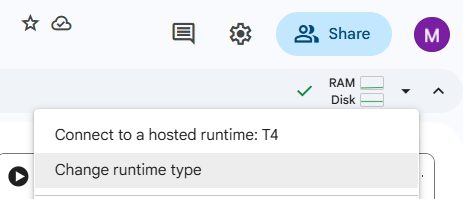<br>
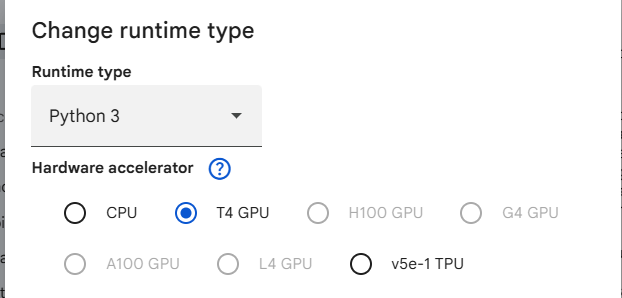

| 선택지 | 장치 (Hardware) | 비유 | 주요 용도 | 비고 |
| :--- | :--- | :--- | :--- | :--- |
| **CPU** | 일반 중앙 처리 장치 | **일반 승용차** | 데이터 로드, 판다스 조작, 단순 시각화 | 기본 설정 (가장 안정적) |
| **T4 GPU** | NVIDIA T4 | **스포츠카** | **딥러닝 모델 학습**, 병렬 연산 (LSTM, CNN 등) | 무료 버전의 핵심 가속기 |
| **TPU v5e** | Google Tensor Unit | **고속열차** | 초대형 데이터셋, 대규모 모델 학습 | 구글 프레임워크 최적화 필요 |
| **A100 / L4** | 고성능 유료 GPU | **슈퍼카** | 대형 언어 모델(LLM), 초고속 연산 | 유료 구독(Pro) 유저용 |

## <b> Train_Test_Split - EDA를 위해서

In [15]:
# 1. date 컬럼을 날짜 형식으로 변환 (필수)
df_train['date'] = pd.to_datetime(df_train['date'])

# 2. date 컬럼을 인덱스로 설정 (이걸 해야 '2017-08-01' 슬라이싱이 가능해짐)
df_train.set_index('date', inplace=True)

# 1. 날짜 데이터가 인덱스인 경우 (아니라면 df_train.set_index('date', inplace=True) 필요)
# Test: 가장 최근 약 보름치 (2017-08-01 ~ 2017-08-15)
test = df_train['2017-08-01':]

# 2. Train / Val: 그 이전 데이터를 날짜로 직접 지정
# 예: 2017년 이전은 학습(Train), 2017년 이후~7월까지는 검증(Val)
train = df_train[:'2016-12-31']
val = df_train['2017-01-01':'2017-07-31']

print(f"Train 기간 : {train.index.min()} ~ {train.index.max()}")
print(f"Val 기간   : {val.index.min()} ~ {val.index.max()}")
print(f"Test 기간  : {test.index.min()} ~ {test.index.max()}")

Train 기간 : 2013-01-01 00:00:00 ~ 2016-12-31 00:00:00
Val 기간   : 2017-01-01 00:00:00 ~ 2017-07-31 00:00:00
Test 기간  : 2017-08-01 00:00:00 ~ 2017-08-15 00:00:00


# <b> EDA

In [16]:
print(df_train.columns)

Index(['id', 'store_nbr', 'family', 'sales', 'onpromotion', 'city', 'state',
       'type_x', 'cluster', 'dcoilwtico', 'type_y', 'locale', 'locale_name',
       'description', 'transferred', 'transactions'],
      dtype='object')


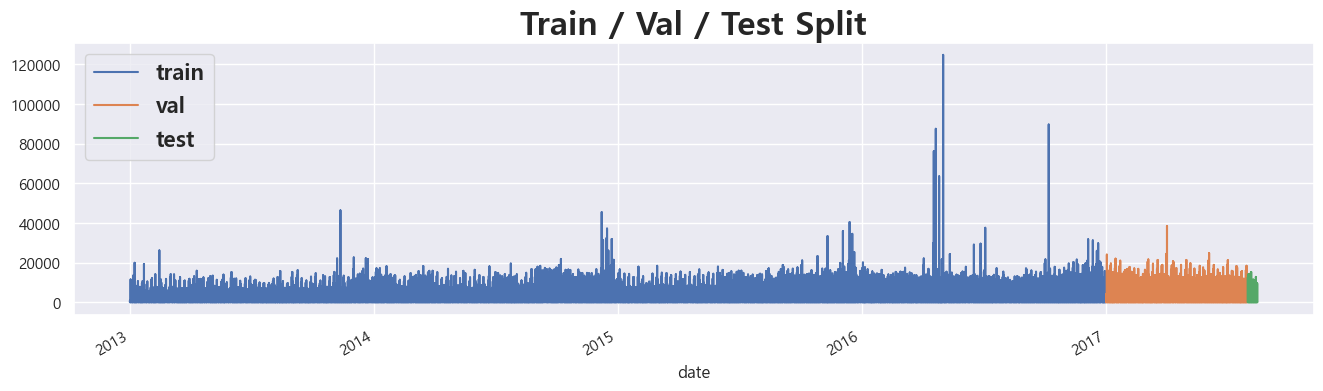

In [17]:
df_train['sales'][: len(train)].plot(figsize=(16,4), legend=True)
df_train['sales'][len(train) : len(train)+len(val)].plot(figsize=(16,4), legend=True)
df_train['sales'][len(train)+len(val) :].plot(figsize=(16,4), legend=True)


plt.title('Train / Val / Test Split', fontweight='bold', fontsize=24)
plt.legend(['train', 'val', 'test'], loc='upper left', prop={'weight': 'bold', 'size': 16})
plt.show();

### <b> 특정 상점(예: store_nbr 1)의 EDA 확인

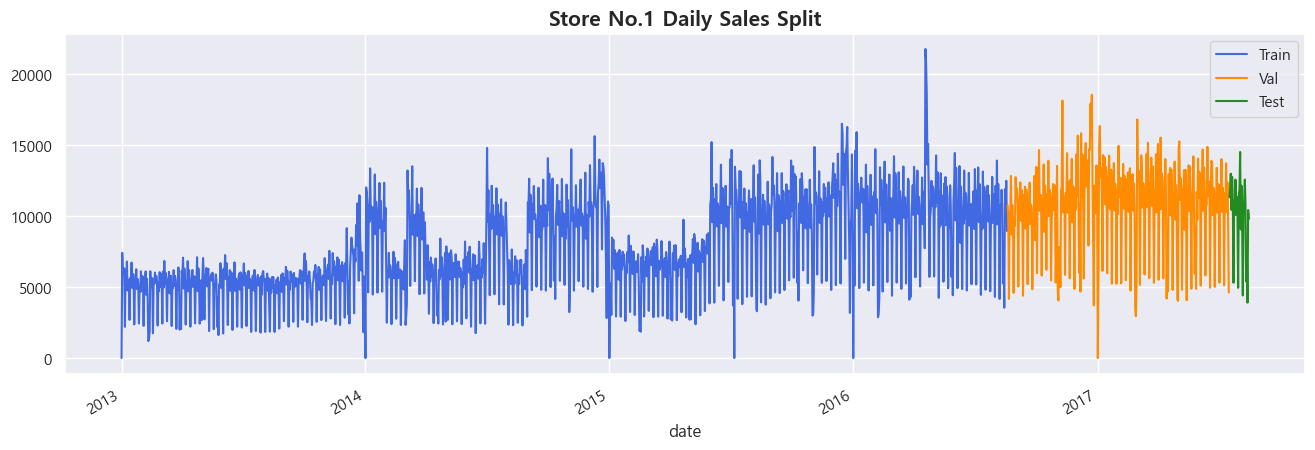

In [18]:
# 특정 상점(예: store_nbr 1)의 데이터만 추출
df_store1 = df_train[df_train['store_nbr'] == 1]

# 날짜별로 판매량 합계 구하기 (품목 상관없이 상점 전체 매출)
df_store1_daily = df_store1.groupby('date')['sales'].sum()

# 다시 분할 (store1_daily 기준)
test_s1 = df_store1_daily[-30:] # 최근 30일
train_val_s1 = df_store1_daily[:-30]
train_s1, val_s1 = train_test_split(train_val_s1, test_size=0.2, shuffle=False)

# 시각화
plt.figure(figsize=(16, 5))
train_s1.plot(label='Train', color='royalblue')
val_s1.plot(label='Val', color='darkorange')
test_s1.plot(label='Test', color='forestgreen')

plt.title('Store No.1 Daily Sales Split', fontweight='bold', fontsize=15)
plt.legend()
plt.show();

### <b> sales 기준 내림차순 정렬하여 상위 10개 확인

In [19]:
# 'date'를 컬럼 리스트에서 제거 (인덱스에 이미 있으므로 자동으로 나옴)
top_sales = df_train.sort_values(by='sales', ascending=False).head(10)

print(top_sales[['store_nbr', 'family', 'sales', 'city']])

            store_nbr     family       sales    city
date                                                
2016-05-02          2  GROCERY I  124717.000   Quito
2016-10-07         39      MEATS   89576.360  Cuenca
2016-04-21         20  GROCERY I   87438.516   Quito
2016-04-18         45  GROCERY I   76090.000   Quito
2016-04-26          2  GROCERY I   63434.000   Quito
2016-04-21         45  GROCERY I   53874.000   Quito
2013-11-12         44  GROCERY I   46271.000   Quito
2014-12-08         35  GROCERY I   45361.000  Playas
2015-12-14         35  GROCERY I   40351.460  Playas
2017-04-02          9  GROCERY I   38422.625   Quito


# <b> 전처리 & 가공
> top 파생피쳐 20개 <br>
> Object 처리 : family, city, state, type<br>
> transaction   : 결측치 처리<br>
> seasonal pattern : sin/cos cycle<br>
> id : drop

In [20]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3000888 entries, 2013-01-01 to 2017-08-15
Data columns (total 16 columns):
 #   Column        Dtype  
---  ------        -----  
 0   id            int64  
 1   store_nbr     int64  
 2   family        object 
 3   sales         float64
 4   onpromotion   int64  
 5   city          object 
 6   state         object 
 7   type_x        object 
 8   cluster       int64  
 9   dcoilwtico    float64
 10  type_y        object 
 11  locale        object 
 12  locale_name   object 
 13  description   object 
 14  transferred   object 
 15  transactions  float64
dtypes: float64(3), int64(4), object(9)
memory usage: 421.5+ MB


## <b> 파생피쳐 

In [21]:
# ============================================================
# 파생 피처 생성 — Cell 39, 40 전체 대체
# ============================================================
import numpy as np
from sklearn.preprocessing import LabelEncoder

df = df_train.copy()

# ------------------------------------------------------------
# 0. 사전 정리
# ------------------------------------------------------------
df.drop(columns=['id'], errors='ignore', inplace=True)

# holiday merge로 생긴 type 컬럼 충돌 정리
# type_x = stores 매장타입(A~E), type_y = holiday 타입
if 'type_x' in df.columns:
    df.rename(columns={'type_x': 'store_type', 'type_y': 'holiday_type'}, inplace=True)

### <b> 1. 날짜 기반 피처
| 피처명 | 설명 |
|--------|------|
| `year` | 연도별 성장 트렌드 |
| `month` | 월별 계절성 (여름/겨울 소비 차이) |
| `day` | 월 중 특정 날짜 패턴 |
| `dayofweek` | 요일 (0=월 ~ 6=일) |
| `weekofyear` | 연중 몇 번째 주 |
| `quarter` | 분기별 계절성 |
| `is_weekend` | 주말 여부 — 주말 매출 급등 패턴 포착 |
| `is_month_start` | 월초 여부 — 급여 직후 소비 증가 포착 |
| `is_month_end` | 월말 여부 — 월말 소비 패턴 포착 |

In [22]:
# ------------------------------------------------------------
# 1. 날짜 기반 피처 (인덱스가 datetime → .index로 접근)
# ------------------------------------------------------------
df['year']           = df.index.year
df['month']          = df.index.month
df['day']            = df.index.day
df['dayofweek']      = df.index.dayofweek        # 0=월 ~ 6=일
df['weekofyear']     = df.index.isocalendar().week.astype(int)
df['quarter']        = df.index.quarter          # 분기별 계절성
df['is_weekend']     = df['dayofweek'].isin([5, 6]).astype(int)
df['is_month_start'] = df.index.is_month_start.astype(int)  # 급여일 소비 패턴
df['is_month_end']   = df.index.is_month_end.astype(int)

### <b> 2. Cyclical Encoding (sin/cos)
> 요일(1~7)을 그냥 숫자로 쓰면 7(일)과 1(월)이 "멀다"고 인식됨
> sin/cos 변환으로 원형 순환 구조를 수치로 정확하게 표현

| 피처명 | 설명 |
|--------|------|
| `dow_sin` / `dow_cos` | 요일 주기성 — 7일 주기 |
| `month_sin` / `month_cos` | 월 주기성 — 12개월 주기 |
| `week_sin` / `week_cos` | 주차 주기성 — 52주 주기 |

In [23]:
# ------------------------------------------------------------
# 2. Cyclical Encoding — 주기성을 수치로 표현
# ------------------------------------------------------------
df['dow_sin']   = np.sin(2 * np.pi * df['dayofweek']  / 7)
df['dow_cos']   = np.cos(2 * np.pi * df['dayofweek']  / 7)
df['month_sin'] = np.sin(2 * np.pi * df['month']      / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month']      / 12)
df['week_sin']  = np.sin(2 * np.pi * df['weekofyear'] / 52)
df['week_cos']  = np.cos(2 * np.pi * df['weekofyear'] / 52)

### <b> 3. 공휴일 피처
| 피처명 | 설명 |
|--------|------|
| `is_holiday` | 공휴일 여부 — 매출 변동 패턴 포착 |

In [24]:
# ------------------------------------------------------------
# 3. 공휴일 피처
# ------------------------------------------------------------
df['is_holiday'] = df.index.isin(holiday['date'].unique()).astype(int)

### <b> 4. 유가(Oil) 피처
| 피처명 | 설명 |
|--------|------|
| `dcoilwtico` | 유가 (보간 처리) — 에콰도르 소비력에 직결 |
| `oil_diff` | 전일 대비 유가 변화량 — 급등/급락 이벤트 포착 |

In [25]:
# ------------------------------------------------------------
# 4. 유가(oil) — 0이 아닌 보간 처리 (핵심!)
# ------------------------------------------------------------
df['dcoilwtico'] = df['dcoilwtico'].interpolate(method='linear').bfill()
df['oil_diff']   = df['dcoilwtico'].diff(1)      # 전일 대비 유가 변화량

### <b> 5. Lag 피처
> 반드시 store + family 그룹별 shift 필요
> 안 하면 A상점 데이터가 B상점 lag로 섞이는 오류 발생

| 피처명 | 설명 |
|--------|------|
| `lag_1` | 1일 전 판매량 |
| `lag_7` | 7일 전 (지난주 같은 요일) |
| `lag_14` | 14일 전 (2주 전 같은 요일) |
| `lag_28` | 28일 전 (한 달 전 같은 요일) |

In [26]:
# ------------------------------------------------------------
# 5. Lag 피처 — 반드시 store+family 그룹별로 shift
# ------------------------------------------------------------
grp = df.groupby(['store_nbr', 'family'])['sales']

for lag in [1, 7, 14, 28]:
    df[f'lag_{lag}'] = grp.shift(lag)

### <b> 6. Rolling Window 피처
> shift(1) 필수 — 안 하면 현재 sales가 자기 자신을 포함해
> 미래 정보가 새는 데이터 누수(Data Leakage) 발생

| 피처명 | 설명 |
|--------|------|
| `rolling_mean_7` | 최근 7일 평균 — 단기 트렌드 |
| `rolling_mean_14` | 최근 14일 평균 — 중기 트렌드 |
| `rolling_mean_28` | 최근 28일 평균 — 장기 트렌드 |
| `rolling_std_7` | 최근 7일 표준편차 — 변동성 포착 |
| `rolling_max_7` | 최근 7일 최대값 — 단기 피크 포착 |
| `rolling_min_7` | 최근 7일 최소값 — 단기 저점 포착 |

In [27]:
# ------------------------------------------------------------
# 6. Rolling Window — shift(1) 필수 (데이터 누수 방지!)
# ------------------------------------------------------------
def roll(x, w):
    return x.shift(1).rolling(window=w, min_periods=1)

df['rolling_mean_7']  = grp.transform(lambda x: roll(x, 7).mean())
df['rolling_mean_14'] = grp.transform(lambda x: roll(x, 14).mean())
df['rolling_mean_28'] = grp.transform(lambda x: roll(x, 28).mean())
df['rolling_std_7']   = grp.transform(lambda x: roll(x, 7).std())
df['rolling_max_7']   = grp.transform(lambda x: roll(x, 7).max())  # 피크 포착
df['rolling_min_7']   = grp.transform(lambda x: roll(x, 7).min())

### <b> 7. Target Encoding (그룹 평균)
> 각 그룹의 평균 판매 수준을 수치로 전달
> Label Encoding보다 판매량 정보를 더 잘 담음

| 피처명 | 설명 |
|--------|------|
| `store_sales_mean` | 매장별 평균 — 매장 규모/인기 반영 |
| `family_sales_mean` | 품목별 평균 — 품목 기본 수요 반영 |
| `store_family_sales_mean` | 매장+품목 조합 평균 |
| `cluster_sales_mean` | 클러스터별 평균 |

In [28]:
# ------------------------------------------------------------
# 7. Target Encoding — 그룹별 판매 수준 기준점
# ------------------------------------------------------------
df['store_sales_mean']         = grp.transform('mean')
df['family_sales_mean']        = df.groupby('family')['sales'].transform('mean')
df['store_family_sales_mean']  = df.groupby(['store_nbr', 'family'])['sales'].transform('mean')
df['cluster_sales_mean']       = df.groupby('cluster')['sales'].transform('mean')

### <b> 8. 프로모션 & 거래량 피처
| 피처명 | 설명 |
|--------|------|
| `transactions_lag1` | 전일 거래 건수 — 방문 고객 수 트렌드 |
| `transactions_roll7` | 최근 7일 평균 거래 건수 — 유동인구 흐름 |
| `promo_ratio` | 프로모션 수 / 매장 평균 판매량 — 프로모션 강도 |

In [29]:
# ------------------------------------------------------------
# 8. 프로모션 & 거래량 피처
# ------------------------------------------------------------
df['transactions_lag1']  = df.groupby('store_nbr')['transactions'].shift(1)
df['transactions_roll7'] = df.groupby('store_nbr')['transactions'].transform(
                               lambda x: x.shift(1).rolling(7, min_periods=1).mean())
df['promo_ratio']        = df['onpromotion'] / (df['store_sales_mean'] + 1)

### <b> 9. 인코딩

In [30]:
# ------------------------------------------------------------
# 9. Object → Label Encoding
# ------------------------------------------------------------
encoder_object = {}
cat_cols = ['family', 'city', 'state', 'store_type', 'holiday_type', 'locale', 'locale_name']
for col in cat_cols:
    if col in df.columns:
        encoder = LabelEncoder()  # 매번 새로 생성
        df[col] = encoder.fit_transform(df[col].fillna('Unknown').astype(str))
        encoder_object[col] = encoder     # 나중에 리버스 인코딩 위해서 넣은 코드

### <b> 10. description, id 드롭 / transferred 수치화

In [31]:
# ------------------------------------------------------------
# 10. description, id 드롭 / transferred 수치화
# ------------------------------------------------------------
df['transferred'] = df['transferred'].map({True: 1, False: 0}).fillna(0).astype(int)
df.drop(columns=['description', 'id'], errors='ignore', inplace=True)

### <b> 11. 결측치 처리

In [32]:
# ------------------------------------------------------------
# 11. 결측치 최종 처리
# ------------------------------------------------------------
lag_roll_cols = [c for c in df.columns if 'lag_' in c or 'rolling_' in c]
df[lag_roll_cols] = df[lag_roll_cols].fillna(0)

df['transactions']       = df['transactions'].fillna(0)
df['transactions_lag1']  = df['transactions_lag1'].fillna(0)
df['transactions_roll7'] = df['transactions_roll7'].fillna(0)
df['oil_diff']           = df['oil_diff'].fillna(0)

### <b> 파생피쳐 처리 후 확인

In [33]:
print("✅ 파생 피처 생성 완료! =================")
df_train = df.copy() 
print(f"총 컬럼 수: {df_train.shape[1]}")
print("========================================= ")
df_train.head(3)

✅ 파생 피처 생성 완료! =================
총 컬럼 수: 48


,store_nbr,family,sales,onpromotion,city,state,store_type,cluster,dcoilwtico,holiday_type,...,rolling_std_7,rolling_max_7,rolling_min_7,store_sales_mean,family_sales_mean,store_family_sales_mean,cluster_sales_mean,transactions_lag1,transactions_roll7,promo_ratio
date,,,,,,,,,,,,,,,,,,,,,
2013-01-01,1,0,0.0,0,18,12,3,13,93.14,3,...,0.0,0.0,0.0,3.251188,6.101236,3.251188,324.364108,0.0,0.0,0.0
2013-01-01,1,1,0.0,0,18,12,3,13,93.14,3,...,0.0,0.0,0.0,0.000000,0.110528,0.000000,324.364108,0.0,0.0,0.0
2013-01-01,1,2,0.0,0,18,12,3,13,93.14,3,...,0.0,0.0,0.0,2.408551,3.715723,2.408551,324.364108,0.0,0.0,0.0


In [34]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3000888 entries, 2013-01-01 to 2017-08-15
Data columns (total 48 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   store_nbr                int64  
 1   family                   int64  
 2   sales                    float64
 3   onpromotion              int64  
 4   city                     int64  
 5   state                    int64  
 6   store_type               int64  
 7   cluster                  int64  
 8   dcoilwtico               float64
 9   holiday_type             int64  
 10  locale                   int64  
 11  locale_name              int64  
 12  transferred              int64  
 13  transactions             float64
 14  year                     int32  
 15  month                    int32  
 16  day                      int32  
 17  dayofweek                int32  
 18  weekofyear               int64  
 19  quarter                  int32  
 20  is_weekend               int64 

In [35]:
print(f" ▶ 최종 컬럼 수: {df_train.shape[1]}")  # 48개
print(" ========================================== ")
print()
df_train.info()

 ▶ 최종 컬럼 수: 48

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3000888 entries, 2013-01-01 to 2017-08-15
Data columns (total 48 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   store_nbr                int64  
 1   family                   int64  
 2   sales                    float64
 3   onpromotion              int64  
 4   city                     int64  
 5   state                    int64  
 6   store_type               int64  
 7   cluster                  int64  
 8   dcoilwtico               float64
 9   holiday_type             int64  
 10  locale                   int64  
 11  locale_name              int64  
 12  transferred              int64  
 13  transactions             float64
 14  year                     int32  
 15  month                    int32  
 16  day                      int32  
 17  dayofweek                int32  
 18  weekofyear               int64  
 19  quarter                  int32  
 20  is_weekend     

## <b> 데이터 분리 & 스케일링

### <b> 0. 시계열 인덱스 정렬

In [36]:
# ------------------------------------------------------------
# 사전 정렬 — store_nbr + family + 날짜 순서 보장 (윈도우 슬라이싱 전 필수)
# ------------------------------------------------------------
df_train = df_train.sort_values(['store_nbr', 'family']).sort_index(level=0, sort_remaining=False)

# 정렬 확인
print(df_train.groupby(['store_nbr', 'family']).apply(lambda x: x.index.is_monotonic_increasing, include_groups=False).all())
# True 면 정상

True


### <b> 1. Train / Val / Test 분리

In [37]:
from sklearn.preprocessing import MinMaxScaler

# ------------------------------------------------------------
# 1. Train / Val / Test 분리 (날짜 기준)
# ------------------------------------------------------------
train = df_train[:'2016-12-31']
val   = df_train['2017-01-01':'2017-07-31']
test  = df_train['2017-08-01':]

### <b> 2. 피처 / 타겟 분리

In [38]:
# ------------------------------------------------------------
# 2. 피처 / 타겟 분리
# ------------------------------------------------------------
target = 'sales'
features = [col for col in df_train.columns if col != target]

X_train, y_train = train[features], train[target]
X_val,   y_val   = val[features],   val[target]
X_test,  y_test  = test[features],  test[target]

### <b> 3. MinMaxScaling

In [39]:
# ------------------------------------------------------------
# 3. 스케일링 — fit은 train만, val/test는 transform만
# ------------------------------------------------------------
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled   = scaler_X.transform(X_val)       # fit 없이 transform만
X_test_scaled  = scaler_X.transform(X_test)      # fit 없이 transform만

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_val_scaled   = scaler_y.transform(y_val.values.reshape(-1, 1))
y_test_scaled  = scaler_y.transform(y_test.values.reshape(-1, 1))

print(f"X_train : {X_train_scaled.shape}")
print(f"X_val   : {X_val_scaled.shape}")
print(f"X_test  : {X_test_scaled.shape}")

X_train : (2596374, 47)
X_val   : (377784, 47)
X_test  : (26730, 47)


## <b>윈도우 슬라이싱

### <b> 1. 시계열 인덱스 순서 정렬

In [40]:
# 윈도우 슬라이싱 전에 반드시 확인
df_train = df_train.sort_index()  # 날짜(인덱스) 기준 오름차순 정렬

# 정렬 확인
print(df_train.index.is_monotonic_increasing)  # True 면 정상

True


### <b> 2. 그룹별 윈도우 슬라이싱

In [41]:
# ------------------------------------------------------------
# 윈도우 슬라이싱 — store + family 그룹별로 독립적으로 슬라이싱
# 전체를 그냥 자르면 매장/상품 경계에서 윈도우가 섞이는 문제 발생
# ------------------------------------------------------------
def make_windows_grouped(df, X_scaled, y_scaled, window_size=7):
    X_windows, y_windows = [], []
    
    start_idx = 0
    for _, group in df.groupby(['store_nbr', 'family']):
        n = len(group)
        if n < window_size:  
            start_idx += n
            continue
        X_group = X_scaled[start_idx : start_idx + n]
        y_group = y_scaled[start_idx : start_idx + n]
        
        # 그룹 내에서만 윈도우 슬라이싱
        for i in range(len(X_group) - window_size):
            X_windows.append(X_group[i : i + window_size])
            y_windows.append(y_group[i + window_size])
        
        start_idx += n
    
    return np.array(X_windows), np.array(y_windows)

In [42]:
# ------------------------------------------------------------
# 적용
# ------------------------------------------------------------
WINDOW_SIZE = 7

X_train_w, y_train_w = make_windows_grouped(train, X_train_scaled, y_train_scaled, WINDOW_SIZE)
X_val_w,   y_val_w   = make_windows_grouped(val,   X_val_scaled,   y_val_scaled,   WINDOW_SIZE)
X_test_w,  y_test_w  = make_windows_grouped(test,  X_test_scaled,  y_test_scaled,  WINDOW_SIZE)

print(f"X_train : {X_train_w.shape}")
print(f"X_val   : {X_val_w.shape}")
print(f"X_test  : {X_test_w.shape}")

X_train : (2583900, 7, 47)
X_val   : (365310, 7, 47)
X_test  : (14256, 7, 47)


In [43]:
print(X_train_w.shape)  # (samples, 7, features)
print(y_train_w.shape)  # (samples, 1)

(2583900, 7, 47)
(2583900, 1)


# <b> Model 학습

### <b> 피처 중요도 확인 방법

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.154313 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5268
[LightGBM] [Info] Number of data points in the train set: 2596374, number of used features: 47
[LightGBM] [Info] Start training from score 338.713869


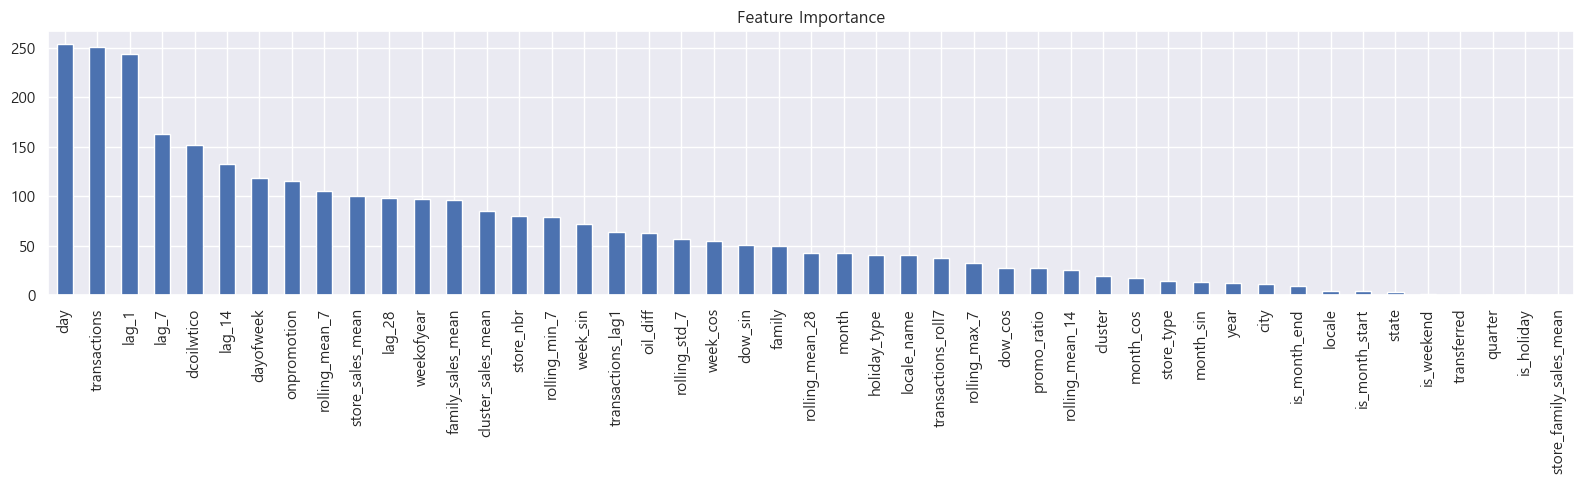

In [44]:
import lightgbm as lgb

# 2D 데이터로 돌려야 하니까 윈도우 슬라이싱 전 데이터 사용
lgb_model = lgb.LGBMRegressor(n_estimators=100, random_state=42)
lgb_model.fit(X_train, y_train)

# 피처 중요도 시각화
import matplotlib.pyplot as plt

importance = pd.Series(lgb_model.feature_importances_, index=features)
importance.sort_values(ascending=False).plot(kind='bar', figsize=(16, 5))
plt.title('Feature Importance')
plt.tight_layout()
plt.show() ;

## <b> (R)MSE, (R)MSLogE 개념 확인 <br>

<pre><b>(R)MSE    : 단순 수치 차이</b>
<b>(R)MSLogE : 비율(증강률)이 중요</b></pre>
| 지표 | 수식 (Formula) | 특징 및 용도 | 비고 |
| :--- | :---: | :--- | :--- |
| **MSE** | $\frac{1}{n} \sum (y_i - \hat{y}_i)^2$ | 오차를 제곱하여 계산. 큰 오차에 매우 민감함. | 학습용 **Loss**로 주로 사용 |
| **RMSE** | $\sqrt{\frac{1}{n} \sum (y_i - \hat{y}_i)^2}$ | MSE에 루트를 씌움. 실제 데이터와 단위가 일치함. | 일반적인 성능 **Metric** |
| **RMSLE** | $\sqrt{\frac{1}{n} \sum (\log(y_i+1) - \log(\hat{y}_i+1))^2}$ | 로그를 씌워 계산. 상대적 비율 오차를 측정함. | 아웃라이어가 많을 때 유리 |
<pre>
－ 증감율에 대한 오차를 계산하고 싶은 경우
－ 작은 수치의 오차에 민감하게 반응해야 하는 경우
－ 성장률/비율이 중요한 경우 - 매출/재고 증강률, 환율, 금리(이자율)
음수값 계산 불가

 y      pred     mse        
100     110      10     ---   10%
1000    1010     10     ---    1%

## <b> 모델 생성 및 평가

<b><big>하이퍼파라미터 설정 가이드

---

<b><big>1. Batch Size
| 데이터 크기 | 권장 Batch Size | 특징 |
|---|---|---|
| 1만 이하 | 32 ~ 128 | - |
| 10만 ~ 100만 | 256 ~ 512 | - |
| 100만 이상 | 512 ~ 2048 | 현재 해당 |

> 크게 잡을수록 학습 빠름 but 일반화 성능 떨어질 수 있음
> 작게 잡을수록 노이즈 많아서 오히려 과적합 방지에 유리할 때도 있음

---

<b><big>2. Epochs
| 전략 | 설명 |
|---|---|
| 권장 범위 | 50 ~ 200 |
| 핵심 | epochs는 크게 잡고 EarlyStopping한테 맡기는 게 국룰 |

---

<b><big>3. Patience
| 상황 | 권장 Patience |
|---|---|
| 빠른 실험 | 3 ~ 5 |
| 일반적인 학습 | 5 ~ 10 |
| 변동이 큰 시계열 | 10 ~ 20 ← 현재 권장 |

> 너무 작으면 아직 개선 여지 있는데 조기종료
> 너무 크면 과적합 상태로 오래 학습

---

<b><big>4. 튜닝 순서
| 순서 | 항목 | 기준 |
|---|---|---|
| 1 | batch_size | 메모리 / 속도 보고 결정 |
| 2 | epochs | 크게 잡고 EarlyStopping 위임 |
| 3 | patience | 학습 곡선 보고 조정 |
| 4 | lr, dropout 등 | 과적합 / 언더핏 보고 조정 |

### <b> 1. 모델 구성 + compile + summary

In [45]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, LSTM, GRU, Bidirectional, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import numpy as np

# ------------------------------------------------------------
# 모델 구성
# ------------------------------------------------------------
model = Sequential([
                        Input(shape=(WINDOW_SIZE, X_train_w.shape[2])),  # 첫 줄에 Input 레이어 추가
                        Bidirectional(LSTM(128, return_sequences=True)),  # input_shape 제거
                        Dropout(0.2),
                        LSTM(64, return_sequences=False),
                        Dropout(0.2),
                        Dense(32, activation='relu'),
                        Dense(1)
                    ])

#                                학습 loss는 mse 유지 (음수 방지)
model.compile( optimizer='adam', loss='mse', metrics=['mae'] )

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)        │ (None, 7, 256)              │         180,224 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 7, 256)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          82,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 264,513 (1.01 MB)

 Trainable params: 264,513 (1.01 MB)

 Non-trainable params: 0 (0.00 B)

### <b> 2. 콜백 정의

In [46]:
# ------------------------------------------------------------
# 콜백
# ------------------------------------------------------------
early_stop = EarlyStopping( monitor='val_loss', patience=5, restore_best_weights=True )

checkpoint = ModelCheckpoint( 'best_model.keras',  monitor='val_loss', save_best_only=True )

### <b> 3. 학습 (fit)

In [47]:
print(tf.config.list_physical_devices('GPU'))

[]


In [48]:
# ------------------------------------------------------------
# 학습
# ------------------------------------------------------------
history = model.fit(
                        X_train_w, y_train_w,
                        validation_data=(X_val_w, y_val_w),
                        epochs=30,
                        batch_size=512,
                        callbacks=[early_stop, checkpoint]
                    )

Epoch 1/30
5047/5047 ━━━━━━━━━━━━━━━━━━━━ 193s 37ms/step - loss: 7.7763e-05 - mae: 0.0040 - val_loss: 1.1877e-04 - val_mae: 0.0052
Epoch 2/30
5047/5047 ━━━━━━━━━━━━━━━━━━━━ 186s 37ms/step - loss: 7.1137e-05 - mae: 0.0039 - val_loss: 1.1879e-04 - val_mae: 0.0051
Epoch 3/30
5047/5047 ━━━━━━━━━━━━━━━━━━━━ 187s 37ms/step - loss: 7.1099e-05 - mae: 0.0039 - val_loss: 1.1873e-04 - val_mae: 0.0052
Epoch 4/30
5047/5047 ━━━━━━━━━━━━━━━━━━━━ 191s 38ms/step - loss: 7.1070e-05 - mae: 0.0039 - val_loss: 1.1871e-04 - val_mae: 0.0052
Epoch 5/30
5047/5047 ━━━━━━━━━━━━━━━━━━━━ 188s 37ms/step - loss: 7.1055e-05 - mae: 0.0039 - val_loss: 1.1863e-04 - val_mae: 0.0052
Epoch 6/30
5047/5047 ━━━━━━━━━━━━━━━━━━━━ 194s 38ms/step - loss: 7.1021e-05 - mae: 0.0039 - val_loss: 1.1860e-04 - val_mae: 0.0053
Epoch 7/30
5047/5047 ━━━━━━━━━━━━━━━━━━━━ 192s 38ms/step - loss: 7.1006e-05 - mae: 0.0039 - val_loss: 1.1860e-04 - val_mae: 0.0053
Epoch 8/30
5047/5047 ━━━━━━━━━━━━━━━━━━━━ 190s 38ms/step - loss: 7.0991e-05 - mae: 

### <b> 4. 예측 + 역변환 + RMSLE

In [49]:
# ------------------------------------------------------------
# 예측 & 역변환
# ------------------------------------------------------------
pred_scaled = model.predict(X_test_w)
pred   = scaler_y.inverse_transform(pred_scaled)
actual = scaler_y.inverse_transform(y_test_w)

# 음수 클리핑 (sales는 음수 없음)
pred   = np.clip(pred, 0, None)
actual = np.clip(actual, 0, None)

# ------------------------------------------------------------
# 성능 확인 — RMSLE (캐글 공식 지표)
# ------------------------------------------------------------
rmsle = np.sqrt(np.mean((np.log1p(pred) - np.log1p(actual)) ** 2))
print(f"RMSLE : {rmsle:.4f}")  # 낮을수록 좋음

446/446 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
RMSLE : 3.5434


### <b> 5. 시각화

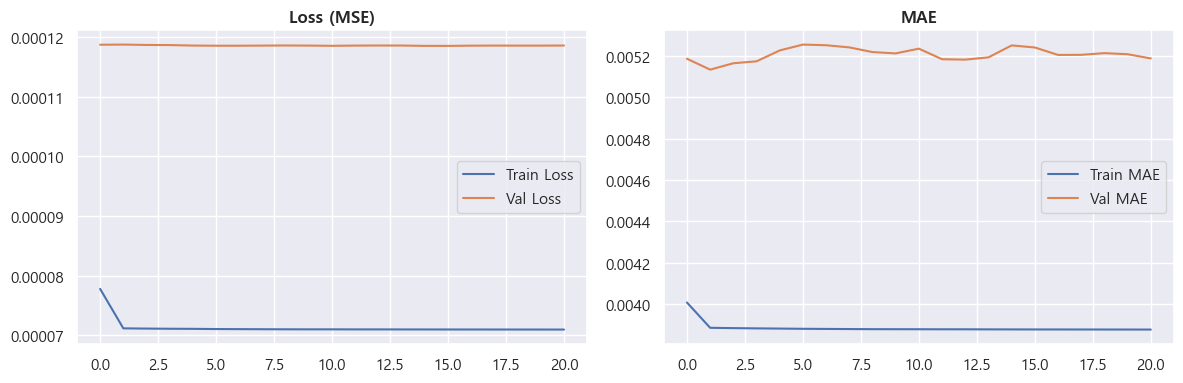

In [50]:
# ------------------------------------------------------------
# 학습 곡선 시각화
# ------------------------------------------------------------
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'],     label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss (MSE)', fontweight='bold')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'],     label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.title('MAE', fontweight='bold')
plt.legend()

plt.tight_layout()
plt.show();